In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mczielinski/bitcoin-historical-data/btcusd_1-min_data.csv


In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')

# GPU memory optimization
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("Available GPUs:", tf.config.list_physical_devices('GPU'))

X shape : (299970, 30, 5)
y shape : (299970,)
Train Shape : (239976, 30, 5)
Test Shape  : (59994, 30, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,273 (55.75 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 136s 9ms/step - loss: 0.0027 - val_loss: 1.4673e-04
Epoch 2/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 135s 9ms/step - loss: 8.6118e-05 - val_loss: 1.3110e-04
Epoch 3/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 139s 9ms/step - loss: 4.9184e-05 - val_loss: 3.9301e-05
Epoch 4/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 137s 9ms/step - loss: 3.9952e-05 - val_loss: 1.0352e-04
Epoch 5/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 135s 9ms/step - loss: 3.4184e-05 - val_loss: 1.3422e-04
Epoch 6/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 130s 9ms/step - loss: 2.9072e-05 - val_loss: 3.6976e-04
Epoch 7/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 131s 9ms/step - loss: 2.6634e-05 - val_loss: 2.4732e-04
Epoch 8/10
14999/14999 ━━━━━━━━━━━━━━━━━━━━ 134s 9ms/step - loss: 2.4312e-05 - val_loss: 3.8258e-04
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

========== MODEL EVALUATION ==========
MSE  : 102583.8856
RMSE : 320.2872
MAE  : 287.6767
R2 Score : 0.9740
Accuracy : 99.63%


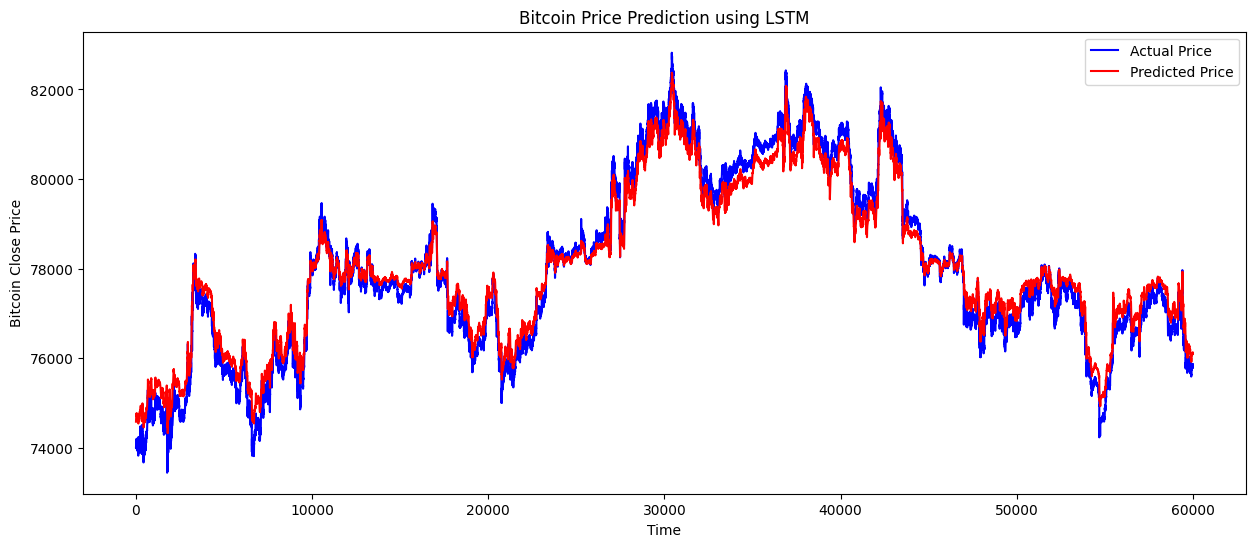

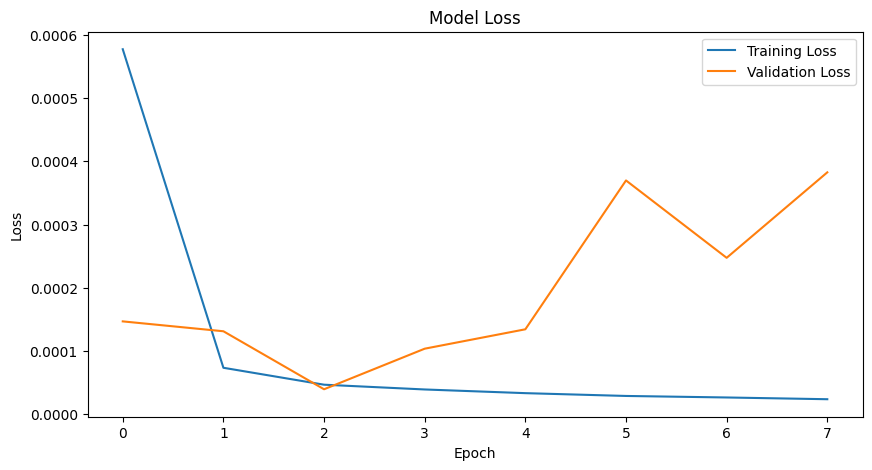


========== FUTURE PREDICTIONS ==========
Minute +1 : 76095.11
Minute +2 : 76092.68
Minute +3 : 76095.45
Minute +4 : 76101.55
Minute +5 : 76109.44
Minute +6 : 76120.15
Minute +7 : 76131.33
Minute +8 : 76140.55
Minute +9 : 76147.13
Minute +10 : 76150.97


In [4]:

# Bitcoin Price Prediction using LSTM


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


df = pd.read_csv(
    "/kaggle/input/datasets/mczielinski/bitcoin-historical-data/btcusd_1-min_data.csv",
    usecols=['Timestamp','Open','High','Low','Close','Volume']
).tail(300000)

# DATA PREPROCESSING


df['Timestamp'] = pd.to_datetime(df['Timestamp'],unit="s")

df = df.sort_values('Timestamp')

df = df.dropna()


# SELECT FEATURES


features = ['Open', 'High', 'Low', 'Close', 'Volume']

data = df[features]


# NORMALIZATION

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

# CREATE SEQUENCES


window_size = 30

X = []
y = []

# Predicting Close Price
close_index = features.index('Close')

for i in range(window_size, len(scaled_data)):

    X.append(scaled_data[i-window_size:i])

    y.append(scaled_data[i, close_index])

X = np.array(X)
y = np.array(y)

print("X shape :", X.shape)
print("y shape :", y.shape)


# TRAIN TEST SPLIT


split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)


# BUILD LSTM MODEL


model = Sequential()

# First LSTM Layer
model.add(LSTM(
    units=32,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(
    units=32,
    return_sequences=False
))

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(32, activation='relu'))

model.add(Dense(1))


# COMPILE MODEL


model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

# EARLY STOPPING


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# TRAIN MODEL


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)


# PREDICTION

predictions = model.predict(X_test)


# INVERSE TRANSFORM


# Create dummy arrays for inverse scaling
dummy_pred = np.zeros((len(predictions), len(features)))
dummy_test = np.zeros((len(y_test), len(features)))

dummy_pred[:, close_index] = predictions.flatten()
dummy_test[:, close_index] = y_test.flatten()

predicted_prices = scaler.inverse_transform(dummy_pred)[:, close_index]
real_prices = scaler.inverse_transform(dummy_test)[:, close_index]


# MODEL EVALUATION


mse = mean_squared_error(real_prices, predicted_prices)

rmse = np.sqrt(mse)

mae = mean_absolute_error(real_prices, predicted_prices)

r2 = r2_score(real_prices, predicted_prices)

# Accuracy Calculation (Approximation)
accuracy = 100 - (np.mean(
    np.abs((real_prices - predicted_prices) / real_prices)
) * 100)

print("\n========== MODEL EVALUATION ==========")

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2 Score : {r2:.4f}")
print(f"Accuracy : {accuracy:.2f}%")


# PLOT RESULTS


plt.figure(figsize=(15,6))

plt.plot(real_prices, color='blue', label='Actual Price')

plt.plot(predicted_prices, color='red', label='Predicted Price')

plt.title('Bitcoin Price Prediction using LSTM')

plt.xlabel('Time')

plt.ylabel('Bitcoin Close Price')

plt.legend()

plt.show()


# LOSS GRAPH


plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()


# FUTURE PREDICTION (NEXT 10 MINUTES)


future_steps = 10

last_sequence = scaled_data[-window_size:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_steps):

    pred = model.predict(
        current_sequence.reshape(1, window_size, len(features)),
        verbose=0
    )

    future_predictions.append(pred[0][0])

    new_row = current_sequence[-1].copy()

    new_row[close_index] = pred[0][0]

    current_sequence = np.vstack([
        current_sequence[1:],
        new_row
    ])

# Inverse transform future predictions
dummy_future = np.zeros((future_steps, len(features)))

dummy_future[:, close_index] = future_predictions

future_prices = scaler.inverse_transform(dummy_future)[:, close_index]

print("\n========== FUTURE PREDICTIONS ==========")

for i, price in enumerate(future_prices):

    print(f"Minute +{i+1} : {price:.2f}")